### Import Library

In [53]:
# Standard library
import warnings
import os
import re
import time

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Model selection
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Model
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score, f1_score,
    precision_score, recall_score, ConfusionMatrixDisplay
)

# Imbalanced data
from imblearn.over_sampling import SMOTE, BorderlineSMOTE

# Save model
import joblib

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

#### Data Understanding

In [54]:
# Load Data
body = pd.read_csv("../dataset/body.csv")
body.columns = [c.strip() for c in body.columns]

print("File body.csv berhasil dimuat")
print(f"Kolom: {list(body.columns)}")

File body.csv berhasil dimuat
Kolom: ['Gender', 'Age', 'HeadCircumference', 'ShoulderWidth', 'ChestWidth', 'Belly', 'Waist', 'Hips', 'ArmLength', 'ShoulderToWaist', 'WaistToKnee', 'LegLength', 'TotalHeight']


In [57]:
# shape dataset
print(f"Shape dataset: {body.shape}")

print("\nInformasi dataset:")
body.info()

Shape dataset: (716, 13)

Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 716 entries, 0 to 715
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             715 non-null    float64
 1   Age                716 non-null    int64  
 2   HeadCircumference  716 non-null    int64  
 3   ShoulderWidth      716 non-null    int64  
 4   ChestWidth         716 non-null    int64  
 5   Belly              716 non-null    int64  
 6   Waist              716 non-null    int64  
 7   Hips               716 non-null    int64  
 8   ArmLength          716 non-null    int64  
 9   ShoulderToWaist    716 non-null    int64  
 10  WaistToKnee        716 non-null    int64  
 11  LegLength          716 non-null    int64  
 12  TotalHeight        716 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 72.8 KB


In [ ]:
print("\nMissing values per kolom:")
print(body.isnull().sum())


Missing values per kolom:
Gender               1
Age                  0
HeadCircumference    0
ShoulderWidth        0
ChestWidth           0
Belly                0
Waist                0
Hips                 0
ArmLength            0
ShoulderToWaist      0
WaistToKnee          0
LegLength            0
TotalHeight          0
dtype: int64


In [59]:
body.head()

,Gender,Age,HeadCircumference,ShoulderWidth,ChestWidth,Belly,Waist,Hips,ArmLength,ShoulderToWaist,WaistToKnee,LegLength,TotalHeight
0,1.0,30,22,18,20,18,14,22,22,25,25,22,52
1,1.0,28,19,22,17,18,21,25,28,23,25,20,56
2,2.0,27,21,18,16,14,10,15,21,18,14,18,53
3,1.0,29,20,20,18,11,19,14,24,21,20,21,45
4,2.0,28,16,14,18,13,11,30,25,22,32,13,47


In [60]:
# Statistik deskriptif
print("Statistik Deskriptif (Kolom Numerik):")
body.describe()

Statistik Deskriptif (Kolom Numerik):


,Gender,Age,HeadCircumference,ShoulderWidth,ChestWidth,Belly,Waist,Hips,ArmLength,ShoulderToWaist,WaistToKnee,LegLength,TotalHeight
count,715.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000
mean,1.453147,15.340782,20.574022,14.317039,14.569832,20.199721,19.265363,19.378492,18.817039,17.900838,16.560056,26.833799,48.118715
std,0.498148,11.831501,3.743353,4.762181,5.314646,10.132993,8.770706,8.745223,5.376592,5.379313,5.204411,7.925988,12.156722
min,1.000000,1.000000,5.000000,4.000000,6.000000,5.000000,2.000000,7.000000,6.000000,1.000000,4.000000,9.000000,19.000000
25%,1.000000,7.000000,19.000000,11.000000,11.000000,15.000000,12.000000,12.000000,16.000000,13.000000,13.000000,21.000000,40.000000
50%,1.000000,11.000000,20.000000,14.000000,13.000000,20.000000,20.000000,18.000000,19.000000,17.500000,16.000000,26.000000,48.000000
75%,2.000000,21.000000,22.000000,18.000000,17.000000,23.000000,23.000000,24.000000,22.000000,22.000000,20.000000,32.000000,55.000000
max,2.000000,68.000000,80.000000,87.000000,38.000000,213.000000,91.000000,63.000000,66.000000,39.000000,45.000000,50.000000,89.000000


#### Data Preparation

In [61]:
# Rename kolom ke bahasa indonesia
body.rename(columns={
    "Gender"             : "jenis_kelamin",
    "Age"                : "usia",
    "HeadCircumference"  : "lingkar_kepala",
    "ShoulderWidth"      : "lebar_bahu",
    "ChestWidth"         : "lebar_dada",
    "Belly"              : "lingkar_perut",
    "Waist"              : "lingkar_pinggang",
    "Hips"               : "lingkar_pinggul",
    "ArmLength"          : "panjang_lengan",
    "ShoulderToWaist"    : "bahu_ke_pinggang",
    "WaistToKnee"        : "pinggang_ke_lutut",
    "LegLength"          : "panjang_kaki",
    "TotalHeight"        : "tinggi_badan"
}, inplace=True)

print("Rename kolom selesai")
print(f"   Kolom baru: {list(body.columns)}")

Rename kolom selesai
   Kolom baru: ['jenis_kelamin', 'usia', 'lingkar_kepala', 'lebar_bahu', 'lebar_dada', 'lingkar_perut', 'lingkar_pinggang', 'lingkar_pinggul', 'panjang_lengan', 'bahu_ke_pinggang', 'pinggang_ke_lutut', 'panjang_kaki', 'tinggi_badan']


In [62]:
body.head()

,jenis_kelamin,usia,lingkar_kepala,lebar_bahu,lebar_dada,lingkar_perut,lingkar_pinggang,lingkar_pinggul,panjang_lengan,bahu_ke_pinggang,pinggang_ke_lutut,panjang_kaki,tinggi_badan
0,1.0,30,22,18,20,18,14,22,22,25,25,22,52
1,1.0,28,19,22,17,18,21,25,28,23,25,20,56
2,2.0,27,21,18,16,14,10,15,21,18,14,18,53
3,1.0,29,20,20,18,11,19,14,24,21,20,21,45
4,2.0,28,16,14,18,13,11,30,25,22,32,13,47


In [9]:
# missing value 
n_missing = body["jenis_kelamin"].isnull().sum()
if n_missing > 0:
    modus = body["jenis_kelamin"].mode()[0]
    body["jenis_kelamin"] = body["jenis_kelamin"].fillna(modus)
    print(f"{n_missing} missing value di 'jenis_kelamin' diisi dengan modus ({modus})")
else:
    print("Tidak ada missing value pada 'jenis_kelamin'")

body["jenis_kelamin"] = body["jenis_kelamin"].astype(int)

1 missing value di 'jenis_kelamin' diisi dengan modus (1.0)


In [10]:
# Hapus Duplikat
n_before = len(body)
body = body.drop_duplicates()
n_after = len(body)

print(f"Jumlah data sebelum  : {n_before:,}")
print(f"Jumlah duplikat      : {n_before - n_after:,}")
print(f"Jumlah data setelah  : {n_after:,}")

body = body.reset_index(drop=True)
body_clean = body.copy()
print("\nPenghapusan duplikat selesai")

Jumlah data sebelum  : 716
Jumlah duplikat      : 17
Jumlah data setelah  : 699

Penghapusan duplikat selesai


In [11]:
# 1. Standar Size Chart (berdasarkan lebar dada & lingkar pinggang)
SIZE_ORDER = ["S", "M", "L", "XL", "XXL"]
size_to_idx = {s: i for i, s in enumerate(SIZE_ORDER)}

size_score = (body["lebar_dada"] + body["lingkar_pinggang"]) / 2
body["ukuran_ideal"], size_bins = pd.qcut(
    size_score, q=5, labels=SIZE_ORDER, retbins=True
)

print("Standar Size Chart (rata-rata lebar dada & lingkar pinggang):")
for i, label in enumerate(SIZE_ORDER):
    print(f"  {label:4s} : {size_bins[i]:.1f} - {size_bins[i+1]:.1f}")

# 2. Simulasikan ukuran yang DICOBA (input pengguna ke sistem fitting)
np.random.seed(42)
idx_ideal = body["ukuran_ideal"].map(size_to_idx).astype(int)

offset = np.random.choice(
    [-2, -1, 0, 1, 2],
    size=len(body),
    p=[0.07, 0.18, 0.50, 0.18, 0.07]
)
idx_dicoba = np.clip(idx_ideal + offset, 0, len(SIZE_ORDER) - 1)
body["ukuran_dicoba"] = [SIZE_ORDER[i] for i in idx_dicoba]

# 3. Target: apakah ukuran yang DICOBA sesuai dengan ukuran IDEAL?
selisih = idx_dicoba - idx_ideal
kondisi = [selisih > 0, selisih < 0]
pilihan = ["Terlalu Besar", "Terlalu Kecil"]
body["kesesuaian_ukuran"] = np.select(kondisi, pilihan, default="Pas")

print("\nKolom target 'kesesuaian_ukuran' berhasil dibuat")
print("(dibandingkan antara 'ukuran_dicoba' vs 'ukuran_ideal' hasil size chart)")
print("\nDistribusi ukuran yang dicoba:")
print(body["ukuran_dicoba"].value_counts()[SIZE_ORDER])
print("\nDistribusi target:")
print(body["kesesuaian_ukuran"].value_counts())

body = body.drop(columns=["ukuran_ideal"])

Standar Size Chart (rata-rata lebar dada & lingkar pinggang):
  S    : 7.0 - 12.0
  M    : 12.0 - 15.0
  L    : 15.0 - 17.0
  XL   : 17.0 - 20.5
  XXL  : 20.5 - 59.5

Kolom target 'kesesuaian_ukuran' berhasil dibuat
(dibandingkan antara 'ukuran_dicoba' vs 'ukuran_ideal' hasil size chart)

Distribusi ukuran yang dicoba:
ukuran_dicoba
S      173
M      131
L      129
XL     115
XXL    151
Name: count, dtype: int64

Distribusi target:
kesesuaian_ukuran
Pas              413
Terlalu Kecil    147
Terlalu Besar    139
Name: count, dtype: int64


In [12]:
# Pindahkan target ke akhir kolom
target = "kesesuaian_ukuran"
cols = [c for c in body.columns if c != target] + [target]
body = body[cols]

print(f"Kolom setelah target dipindahkan ke akhir: {list(body.columns)}")

Kolom setelah target dipindahkan ke akhir: ['jenis_kelamin', 'usia', 'lingkar_kepala', 'lebar_bahu', 'lebar_dada', 'lingkar_perut', 'lingkar_pinggang', 'lingkar_pinggul', 'panjang_lengan', 'bahu_ke_pinggang', 'pinggang_ke_lutut', 'panjang_kaki', 'tinggi_badan', 'ukuran_dicoba', 'kesesuaian_ukuran']


#### Feature Engineering

In [13]:
# 1. Kelompok Usia
USIA_BINS = [0, 5, 10, 15, 20, 30, 100]
USIA_LABELS = [0, 1, 2, 3, 4, 5]
body["usia_group"] = pd.cut(
    body["usia"], bins=USIA_BINS, labels=USIA_LABELS
).astype(int)

# 2. Kategori Tinggi Badan
TINGGI_LABELS = ["Pendek", "Sedang", "Tinggi", "Sangat Tinggi"]
body["kategori_tinggi"], TINGGI_BINS = pd.qcut(
    body["tinggi_badan"], q=4,
    labels=TINGGI_LABELS, retbins=True
)
body["kategori_tinggi"] = body["kategori_tinggi"].astype(str)

# Perluas batas bawah & atas jadi -inf/inf agar data baru yang lebih kecil/besar
TINGGI_BINS = TINGGI_BINS.copy()
TINGGI_BINS[0] = -np.inf
TINGGI_BINS[-1] = np.inf

print("(check) Feature engineering selesai, 2 fitur baru berhasil dibuat")
print(f"  Batas kategori tinggi badan (otomatis dari data training): {TINGGI_BINS}")

(check) Feature engineering selesai, 2 fitur baru berhasil dibuat
  Batas kategori tinggi badan (otomatis dari data training): [-inf  41.  48.  55.  inf]


In [14]:
# Validasi Hasil Feature Engineering
print("5 baris pertama dataset setelah feature engineering:")
display(body.head())

print("\nInformasi dataset:")
body.info()

print(f"\nJumlah fitur (tidak termasuk target) : {body.shape[1] - 1}")
print(f"Jumlah total kolom (termasuk target)  : {body.shape[1]}")

print("\nJumlah missing value per kolom:")
print(body.isnull().sum())
print(f"\nTotal missing value di seluruh dataset: {body.isnull().sum().sum()}")

5 baris pertama dataset setelah feature engineering:


,jenis_kelamin,usia,lingkar_kepala,lebar_bahu,lebar_dada,lingkar_perut,lingkar_pinggang,lingkar_pinggul,panjang_lengan,bahu_ke_pinggang,pinggang_ke_lutut,panjang_kaki,tinggi_badan,ukuran_dicoba,kesesuaian_ukuran,usia_group,kategori_tinggi
0,1,30,22,18,20,18,14,22,22,25,25,22,52,L,Pas,4,Tinggi
1,1,28,19,22,17,18,21,25,28,23,25,20,56,XXL,Terlalu Besar,4,Sangat Tinggi
2,2,27,21,18,16,14,10,15,21,18,14,18,53,M,Pas,4,Tinggi
3,1,29,20,20,18,11,19,14,24,21,20,21,45,XL,Pas,4,Sedang
4,2,28,16,14,18,13,11,30,25,22,32,13,47,S,Terlalu Kecil,4,Sedang



Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   jenis_kelamin      699 non-null    int64
 1   usia               699 non-null    int64
 2   lingkar_kepala     699 non-null    int64
 3   lebar_bahu         699 non-null    int64
 4   lebar_dada         699 non-null    int64
 5   lingkar_perut      699 non-null    int64
 6   lingkar_pinggang   699 non-null    int64
 7   lingkar_pinggul    699 non-null    int64
 8   panjang_lengan     699 non-null    int64
 9   bahu_ke_pinggang   699 non-null    int64
 10  pinggang_ke_lutut  699 non-null    int64
 11  panjang_kaki       699 non-null    int64
 12  tinggi_badan       699 non-null    int64
 13  ukuran_dicoba      699 non-null    str  
 14  kesesuaian_ukuran  699 non-null    str  
 15  usia_group         699 non-null    int64
 16  kategori_tinggi    699 non-null    str  
dtypes: int6

#### Exploratory Data Analysis (EDA)

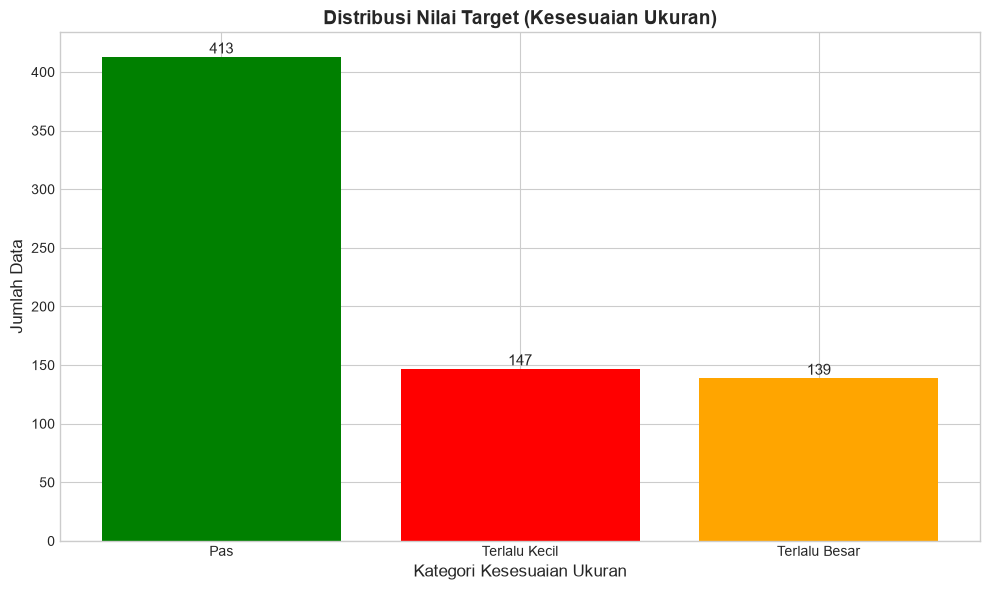


Distribusi target:
kesesuaian_ukuran
Pas              413
Terlalu Kecil    147
Terlalu Besar    139
Name: count, dtype: int64


In [15]:
# VISUALISASI DISTRIBUSI TARGET
plt.figure(figsize=(10, 6))
target_counts = body["kesesuaian_ukuran"].value_counts()
colors = ["green", "red", "orange"]
bars = plt.bar(target_counts.index, target_counts.values, color=colors[:len(target_counts)])
plt.title("Distribusi Nilai Target (Kesesuaian Ukuran)", fontsize=14, fontweight="bold")
plt.xlabel("Kategori Kesesuaian Ukuran", fontsize=12)
plt.ylabel("Jumlah Data", fontsize=12)
plt.xticks(rotation=0)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f"{int(height)}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()
print(f"\nDistribusi target:\n{target_counts}")

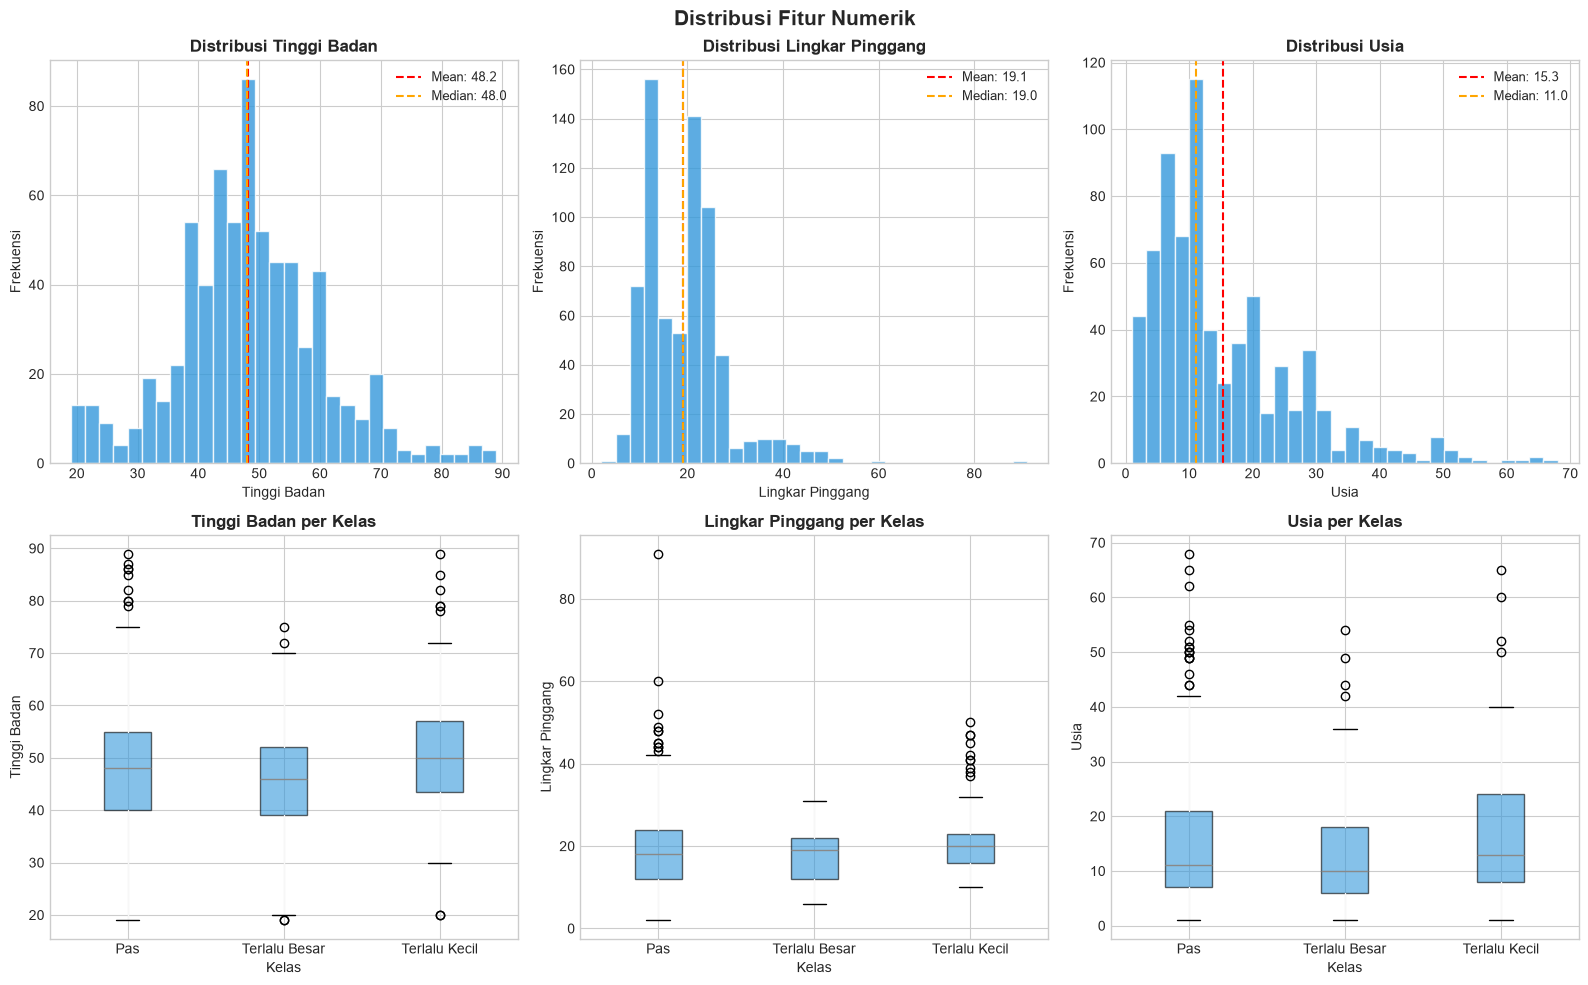

In [16]:
# Distribusi Fitur Numerik
num_features = ["tinggi_badan", "lingkar_pinggang", "usia"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, feat in enumerate(num_features):
    ax = axes[0][idx]
    body[feat].hist(ax=ax, bins=30, color="#3498db", edgecolor="white", alpha=0.8)
    ax.axvline(body[feat].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean: {body[feat].mean():.1f}")
    ax.axvline(body[feat].median(), color="orange", linestyle="--", linewidth=1.5, label=f"Median: {body[feat].median():.1f}")
    ax.set_title(f"Distribusi {feat.replace(chr(95),chr(32)).title()}", fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_xlabel(feat.replace("_", " ").title())
    ax.set_ylabel("Frekuensi")

    ax2 = axes[1][idx]
    body.boxplot(column=feat, by="kesesuaian_ukuran", ax=ax2,
                 patch_artist=True,
                 boxprops=dict(facecolor="#3498db", alpha=0.6))
    ax2.set_title(f"{feat.replace(chr(95),chr(32)).title()} per Kelas", fontweight="bold")
    ax2.set_xlabel("Kelas")
    ax2.set_ylabel(feat.replace("_", " ").title())

plt.suptitle("Distribusi Fitur Numerik", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

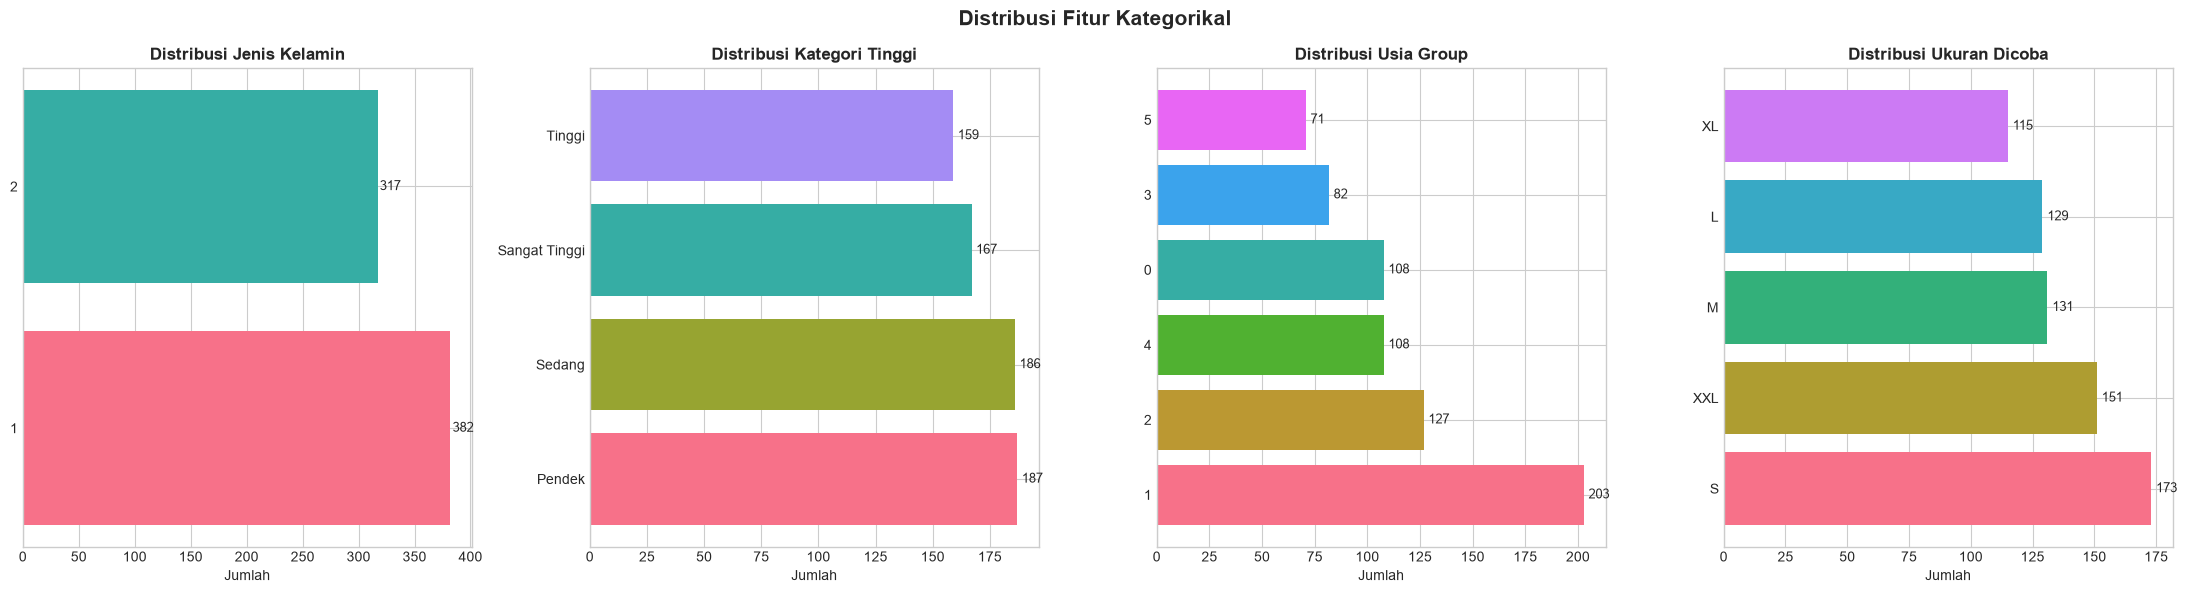

In [17]:
# Distribusi Fitur Kategorikal
cat_features = ["jenis_kelamin", "kategori_tinggi", "usia_group", "ukuran_dicoba"]
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for idx, feat in enumerate(cat_features):
    ax = axes[idx]
    vc = body[feat].astype(str).value_counts()
    bars = ax.barh(vc.index, vc.values, color=sns.color_palette("husl", len(vc)))
    ax.set_title(f"Distribusi {feat.replace(chr(95),chr(32)).title()}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Jumlah")
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 2, bar.get_y() + bar.get_height()/2,
                f"{int(w):,}", va="center", fontsize=9)

plt.suptitle("Distribusi Fitur Kategorikal", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

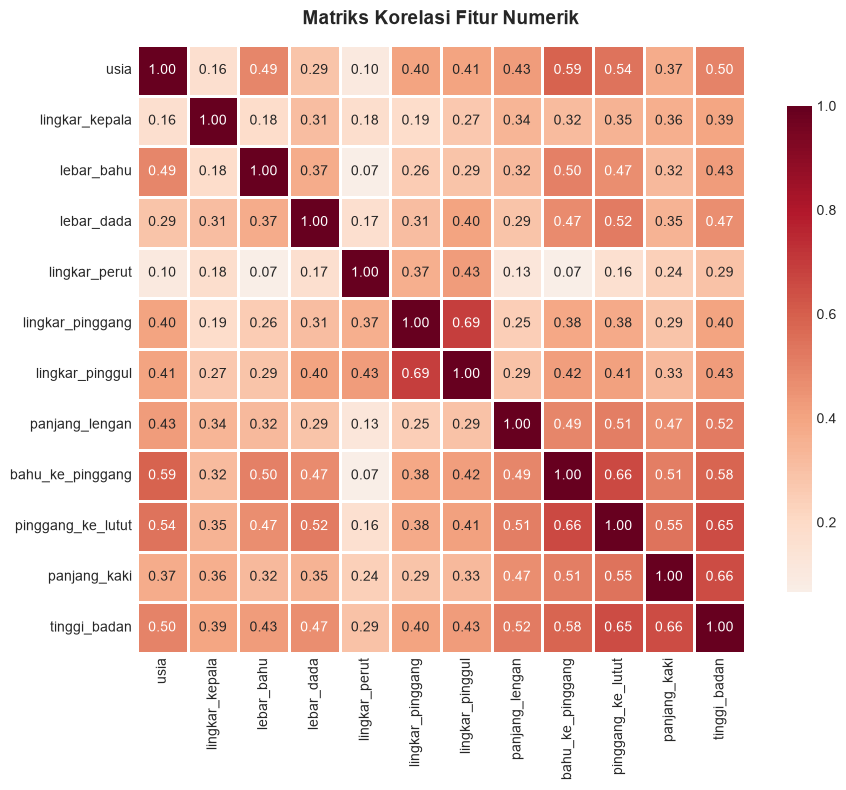

In [18]:
# Korelasi Fitur Numerik
fig, ax = plt.subplots(figsize=(10, 8))

num_data = body[["usia", "lingkar_kepala", "lebar_bahu", "lebar_dada", "lingkar_perut",
                  "lingkar_pinggang", "lingkar_pinggul", "panjang_lengan",
                  "bahu_ke_pinggang", "pinggang_ke_lutut", "panjang_kaki", "tinggi_badan"]].copy()
corr = num_data.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, ax=ax,
            linewidths=1, linecolor="white",
            cbar_kws={"shrink": 0.8})
ax.set_title("Matriks Korelasi Fitur Numerik", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

In [19]:
body.head()

,jenis_kelamin,usia,lingkar_kepala,lebar_bahu,lebar_dada,lingkar_perut,lingkar_pinggang,lingkar_pinggul,panjang_lengan,bahu_ke_pinggang,pinggang_ke_lutut,panjang_kaki,tinggi_badan,ukuran_dicoba,kesesuaian_ukuran,usia_group,kategori_tinggi
0,1,30,22,18,20,18,14,22,22,25,25,22,52,L,Pas,4,Tinggi
1,1,28,19,22,17,18,21,25,28,23,25,20,56,XXL,Terlalu Besar,4,Sangat Tinggi
2,2,27,21,18,16,14,10,15,21,18,14,18,53,M,Pas,4,Tinggi
3,1,29,20,20,18,11,19,14,24,21,20,21,45,XL,Pas,4,Sedang
4,2,28,16,14,18,13,11,30,25,22,32,13,47,S,Terlalu Kecil,4,Sedang


#### Encoding, Scaling & Pembagian Data

In [20]:
# Simpan label encoder target
le_target = LabelEncoder()
body["kesesuaian_ukuran_enc"] = le_target.fit_transform(body["kesesuaian_ukuran"])

print("Mapping label target:")
for i, cls in enumerate(le_target.classes_):
    print(f"  {i} \u2192 {cls}")

ORDINAL_FEATURES = {
    "ukuran_dicoba": SIZE_ORDER,        # ["S", "M", "L", "XL", "XXL"]
    "kategori_tinggi": TINGGI_LABELS,   # ["Pendek", "Sedang", "Tinggi", "Sangat Tinggi"]
}

feature_encoders = {}
cat_feats = body.select_dtypes(include=["object", "category"]).columns.tolist()
cat_feats = [c for c in cat_feats if c != "kesesuaian_ukuran"]

print("\nEncoding fitur kategorikal:")
for col in cat_feats:
    if col in ORDINAL_FEATURES:
        # Encoding ORDINAL manual (bukan LabelEncoder alfabetis)
        order = ORDINAL_FEATURES[col]
        mapping = {cat: i for i, cat in enumerate(order)}
        body[col] = body[col].astype(str).map(mapping)
        feature_encoders[col] = mapping  # simpan sebagai dict {kategori: kode}
        print(f"  \u2713 {col} \u2192 encoding ORDINAL sesuai urutan asli: {order}")
    else:
        # Fallback: kolom kategorikal lain (nominal, bukan ordinal) tetap
        # pakai LabelEncoder biasa
        le = LabelEncoder()
        body[col] = le.fit_transform(body[col].astype(str))
        feature_encoders[col] = le
        print(f"  \u2713 {col} \u2192 {len(le.classes_)} kelas unik (LabelEncoder alfabetis)")

# Drop kolom target asli, gunakan yang sudah encoded
body = body.drop("kesesuaian_ukuran", axis=1)
body = body.rename(columns={"kesesuaian_ukuran_enc": "kesesuaian_ukuran"})

print("\n(check) Encoding selesai")
print(f"   Shape akhir: {body.shape}")
print(f"   Semua numerik: {all(body.dtypes != object)}")


Mapping label target:
  0 → Pas
  1 → Terlalu Besar
  2 → Terlalu Kecil

Encoding fitur kategorikal:
  ✓ ukuran_dicoba → encoding ORDINAL sesuai urutan asli: ['S', 'M', 'L', 'XL', 'XXL']
  ✓ kategori_tinggi → encoding ORDINAL sesuai urutan asli: ['Pendek', 'Sedang', 'Tinggi', 'Sangat Tinggi']

(check) Encoding selesai
   Shape akhir: (699, 17)
   Semua numerik: True


In [21]:
os.makedirs("../dataset", exist_ok=True)
body.to_csv("../dataset/body_clean.csv", index=False)
print("Dataset bersih disimpan ke '../dataset/body_clean.csv'")

Dataset bersih disimpan ke '../dataset/body_clean.csv'


In [22]:
# Pisah Fitur & Target
X = body.drop("kesesuaian_ukuran", axis=1)
y = body["kesesuaian_ukuran"]

feature_names = X.columns.tolist()

print(f"Shape X (fitur)  : {X.shape}")
print(f"Shape y (target) : {y.shape}")
print(f"\nDaftar fitur ({len(feature_names)}):")
for i, f in enumerate(feature_names, 1):
    print(f"  {i:2d}. {f}")

Shape X (fitur)  : (699, 16)
Shape y (target) : (699,)

Daftar fitur (16):
   1. jenis_kelamin
   2. usia
   3. lingkar_kepala
   4. lebar_bahu
   5. lebar_dada
   6. lingkar_perut
   7. lingkar_pinggang
   8. lingkar_pinggul
   9. panjang_lengan
  10. bahu_ke_pinggang
  11. pinggang_ke_lutut
  12. panjang_kaki
  13. tinggi_badan
  14. ukuran_dicoba
  15. usia_group
  16. kategori_tinggi


In [23]:
# Split Train-Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("  PEMBAGIAN DATASET (SEBELUM SCALING & SMOTE)")
print(f"  Total data     : {len(X):,}")
print(f"  Data training  : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Data testing   : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")
print("\nDistribusi kelas training:")
for k, v in pd.Series(y_train).value_counts().items():
    print(f"  {le_target.classes_[k]}: {v:,}")
print("\nDistribusi kelas testing:")
for k, v in pd.Series(y_test).value_counts().items():
    print(f"  {le_target.classes_[k]}: {v:,}")


  PEMBAGIAN DATASET (SEBELUM SCALING & SMOTE)
  Total data     : 699
  Data training  : 559 (80%)
  Data testing   : 140  (20%)

Distribusi kelas training:
  Pas: 330
  Terlalu Kecil: 118
  Terlalu Besar: 111

Distribusi kelas testing:
  Pas: 83
  Terlalu Kecil: 29
  Terlalu Besar: 28


In [24]:
# Validation Split (diambil dari data training, SEBELUM SMOTE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print(f"Data training (sebelum SMOTE) : {X_train.shape[0]:,}")
print(f"Data validasi (real, tidak di-SMOTE): {X_val.shape[0]:,}")

print("\nDistribusi kelas training sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

smote = BorderlineSMOTE(random_state=42, k_neighbors=3, kind="borderline-1")
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nDistribusi kelas training setelah SMOTE:")
vc_after = pd.Series(y_train).value_counts()
for k, v in vc_after.items():
    print(f"  Kelas {k} ({le_target.classes_[k]}): {v:,}")
print(f"\nShape setelah SMOTE: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Shape X_val (tidak di-resample) : {X_val.shape}")
print(f"Shape X_test (tidak di-resample): {X_test.shape}")

Data training (sebelum SMOTE) : 475
Data validasi (real, tidak di-SMOTE): 84

Distribusi kelas training sebelum SMOTE:
kesesuaian_ukuran
0    281
2    100
1     94
Name: count, dtype: int64

Distribusi kelas training setelah SMOTE:
  Kelas 1 (Terlalu Besar): 281
  Kelas 0 (Pas): 281
  Kelas 2 (Terlalu Kecil): 281

Shape setelah SMOTE: X_train=(843, 16), y_train=(843,)
Shape X_val (tidak di-resample) : (84, 16)
Shape X_test (tidak di-resample): (140, 16)


#### Modeling dan Evaluation

In [25]:
# Hyperparameter Tuning - RandomizedSearchCV
xgb_base = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "max_depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "n_estimators": [100, 200, 300, 400, 500],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.85, 0.9, 1.0],
    "gamma": [0, 0.1, 0.15, 0.2, 0.3],
    "min_child_weight": [1, 2, 3, 5],
    "reg_alpha": [0, 0.05, 0.1, 0.5],
    "reg_lambda": [1, 1.5, 2, 3]
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring='accuracy',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_params = random_search.best_params_

cv_results_sorted = pd.DataFrame(random_search.cv_results_).sort_values(
    "mean_test_score", ascending=False
).reset_index(drop=True)

print("Parameter Terbaik (hasil RandomizedSearchCV):")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest CV Accuracy: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Parameter Terbaik (hasil RandomizedSearchCV):
  subsample: 0.9
  reg_lambda: 2
  reg_alpha: 0
  n_estimators: 300
  min_child_weight: 2
  max_depth: 7
  learning_rate: 0.07
  gamma: 0.15
  colsample_bytree: 0.7

Best CV Accuracy: 0.9312


In [26]:
# model 1 
model1_params = dict(
    max_depth=3,
    n_estimators=80,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=1,
)

model1 = XGBClassifier(
    **model1_params,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
)

print("Training model 1 (Baseline)...")
model1.fit(X_train, y_train, verbose=False)

y_pred1 = model1.predict(X_test)
y_pred_proba1 = model1.predict_proba(X_test)

acc1 = accuracy_score(y_test, y_pred1)
auc1 = roc_auc_score(y_test, y_pred_proba1, multi_class="ovr", average="macro")

print("\n=== model 1 (Baseline) ===")
print(f"Akurasi: {acc1:.4f} ({acc1*100:.2f}%)")
print(f"AUC Score: {auc1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred1))


Training model 1 (Baseline)...

=== model 1 (Baseline) ===
Akurasi: 0.6786 (67.86%)
AUC Score: 0.8957

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.55      0.68        83
           1       0.46      0.82      0.59        28
           2       0.68      0.90      0.78        29

    accuracy                           0.68       140
   macro avg       0.68      0.76      0.68       140
weighted avg       0.76      0.68      0.68       140



In [27]:
# Penentuan parameter model 2 & model 3
model2_params = dict(
    max_depth=5,
    n_estimators=250,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.1,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.5,
)

model3_params = dict(best_params)  

def _val_acc(params, X_tr, y_tr, X_v, y_v):
    m = XGBClassifier(
        **params,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )
    m.fit(X_tr, y_tr, verbose=False)
    pred = m.predict(X_v)
    return accuracy_score(y_v, pred)

acc1_val = _val_acc(model1_params, X_train, y_train, X_val, y_val)
acc2_val = _val_acc(model2_params, X_train, y_train, X_val, y_val)
acc3_val = _val_acc(model3_params, X_train, y_train, X_val, y_val)

print("Akurasi pada VALIDATION SET (informasi, bukan dasar pemilihan parameter):")
print(f"  model 1 (baseline) : {acc1_val:.4f}")
print(f"  model 2 (improved) : {acc2_val:.4f}")
print(f"  model 3 (optimal)  : {acc3_val:.4f}")

if not (acc1_val < acc2_val < acc3_val):
    print("\n⚠️ Akurasi validation belum naik bertahap (model1 < model2 < model3).")
    print("   Silakan sesuaikan sedikit model1_params/model2_params di atas")
    print("   (mis. naikkan max_depth/n_estimators model2, atau turunkan kapasitas")
    print("   model1), lalu jalankan ulang cell ini sampai urutannya bertahap.")
else:
    print("\n✓ Akurasi validation sudah naik bertahap sesuai urutan model 1 < model 2 < model 3.")

print("\nParameter model 2 (fixed/manual):")
for k, v in model2_params.items():
    print(f"  {k}: {v}")

print("\nParameter model 3 (best_params dari RandomizedSearchCV):")
for k, v in model3_params.items():
    print(f"  {k}: {v}")

Akurasi pada VALIDATION SET (informasi, bukan dasar pemilihan parameter):
  model 1 (baseline) : 0.8571
  model 2 (improved) : 0.9167
  model 3 (optimal)  : 0.9286

✓ Akurasi validation sudah naik bertahap sesuai urutan model 1 < model 2 < model 3.

Parameter model 2 (fixed/manual):
  max_depth: 5
  n_estimators: 250
  learning_rate: 0.08
  subsample: 0.85
  colsample_bytree: 0.85
  gamma: 0.1
  min_child_weight: 3
  reg_alpha: 0.1
  reg_lambda: 1.5

Parameter model 3 (best_params dari RandomizedSearchCV):
  subsample: 0.9
  reg_lambda: 2
  reg_alpha: 0
  n_estimators: 300
  min_child_weight: 2
  max_depth: 7
  learning_rate: 0.07
  gamma: 0.15
  colsample_bytree: 0.7


ROC CURVE - model 1 (Baseline)


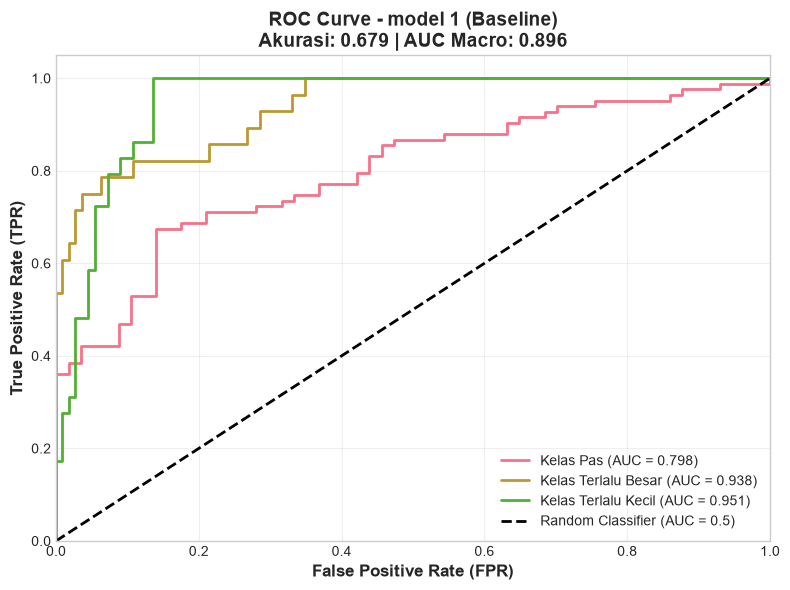

In [28]:
# model 1 - ROC CURVE
print("ROC CURVE - model 1 (Baseline)")

plt.figure(figsize=(8, 6))

n_classes = len(np.unique(y_test))
class_names = list(le_target.classes_)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_proba1[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"Kelas {class_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=2, label="Random Classifier (AUC = 0.5)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate (TPR)", fontsize=12, fontweight="bold")
plt.title(f"ROC Curve - model 1 (Baseline)\nAkurasi: {acc1:.3f} | AUC Macro: {auc1:.3f}",
          fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# model 2
model2 = XGBClassifier(
    **model2_params,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
)

print("Training model 2 (Improved)...")
print("Parameter model 2 (terpilih dari validation set):")
for k, v in model2_params.items():
    print(f"  {k}: {v}")

model2.fit(X_train, y_train, verbose=False)

y_pred2 = model2.predict(X_test)
y_pred_proba2 = model2.predict_proba(X_test)

acc2 = accuracy_score(y_test, y_pred2)
auc2 = roc_auc_score(y_test, y_pred_proba2, multi_class="ovr", average="macro")

print("\n=== model 2 (Improved) ===")
print(f"Akurasi: {acc2:.4f} ({acc2*100:.2f}%)")
print(f"AUC Score: {auc2:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred2))

Training model 2 (Improved)...
Parameter model 2 (terpilih dari validation set):
  max_depth: 5
  n_estimators: 250
  learning_rate: 0.08
  subsample: 0.85
  colsample_bytree: 0.85
  gamma: 0.1
  min_child_weight: 3
  reg_alpha: 0.1
  reg_lambda: 1.5

=== model 2 (Improved) ===
Akurasi: 0.8429 (84.29%)
AUC Score: 0.9631

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86        83
           1       0.80      0.86      0.83        28
           2       0.74      0.90      0.81        29

    accuracy                           0.84       140
   macro avg       0.82      0.86      0.83       140
weighted avg       0.85      0.84      0.84       140



ROC CURVE - model 2 (Improved)


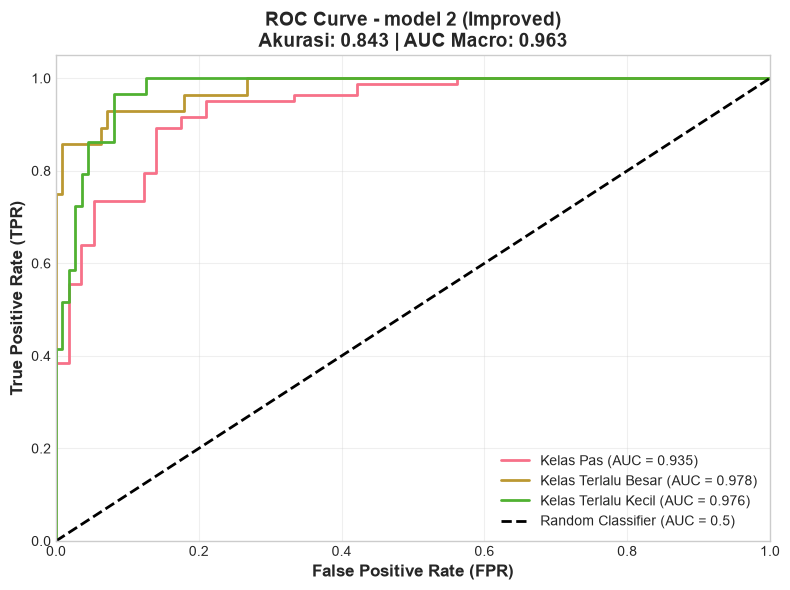

In [30]:
# model 2 - ROC CURVE
print("ROC CURVE - model 2 (Improved)")

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_proba2[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"Kelas {class_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=2, label="Random Classifier (AUC = 0.5)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate (TPR)", fontsize=12, fontweight="bold")
plt.title(f"ROC Curve - model 2 (Improved)\nAkurasi: {acc2:.3f} | AUC Macro: {auc2:.3f}",
          fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# model 3 
model3 = XGBClassifier(
    **model3_params,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
)

print("Training model 3 (Optimal)...")
print("Parameter model 3 (terpilih dari validation set):")
for k, v in model3_params.items():
    print(f"  {k}: {v}")

model3.fit(X_train, y_train, verbose=False)

y_pred3 = model3.predict(X_test)
y_pred_proba3 = model3.predict_proba(X_test)

acc3 = accuracy_score(y_test, y_pred3)
auc3 = roc_auc_score(y_test, y_pred_proba3, multi_class="ovr", average="macro")

print("\n=== model 3 (Optimal) ===")
print(f"Akurasi: {acc3:.4f} ({acc3*100:.2f}%)")
print(f"AUC Score: {auc3:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred3))

Training model 3 (Optimal)...
Parameter model 3 (terpilih dari validation set):
  subsample: 0.9
  reg_lambda: 2
  reg_alpha: 0
  n_estimators: 300
  min_child_weight: 2
  max_depth: 7
  learning_rate: 0.07
  gamma: 0.15
  colsample_bytree: 0.7

=== model 3 (Optimal) ===
Akurasi: 0.8429 (84.29%)
AUC Score: 0.9548

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86        83
           1       0.83      0.86      0.84        28
           2       0.72      0.90      0.80        29

    accuracy                           0.84       140
   macro avg       0.82      0.86      0.83       140
weighted avg       0.85      0.84      0.84       140



ROC CURVE - model 3 (Optimal)


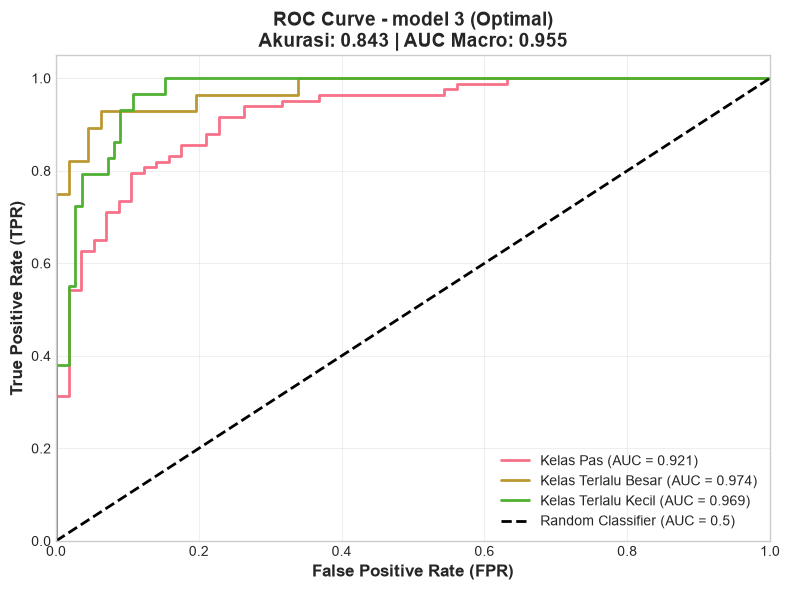

In [32]:
# model 3 - ROC CURVE
print("ROC CURVE - model 3 (Optimal)")

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_proba3[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"Kelas {class_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=2, label="Random Classifier (AUC = 0.5)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate (TPR)", fontsize=12, fontweight="bold")
plt.title(f"ROC Curve - model 3 (Optimal)\nAkurasi: {acc3:.3f} | AUC Macro: {auc3:.3f}",
          fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# TRAIN FINAL model
final_model = XGBClassifier(
    **model3_params,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0
)

print("\nMelatih model XGBoost final (parameter sama dengan model 3)...")
final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print("✓ Training selesai")


Melatih model XGBoost final (parameter sama dengan model 3)...
✓ Training selesai


In [34]:
# EVALUASI model
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
auc_score = roc_auc_score(y_test, y_pred_proba, multi_class="ovr", average="macro")

print("HASIL EVALUASI model XGBOOST FINAL")
print(f"Akurasi: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print(f"AUC Score (macro): {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

print(f"\nPerbandingan dengan model 3: akurasi model 3 = {acc3*100:.2f}%, akurasi final model = {accuracy*100:.2f}%")
if abs(accuracy - acc3) < 1e-9:
    print("✓ Final model menghasilkan akurasi yang SAMA PERSIS dengan model 3 (parameter identik).")
else:
    print("⚠️ Ada perbedaan kecil, cek kembali parameter final_model vs model3.")

HASIL EVALUASI model XGBOOST FINAL
Akurasi: 0.8429 (84.29%)
Precision (weighted): 0.8526
Recall (weighted): 0.8429
F1-Score (weighted): 0.8444
AUC Score (macro): 0.9548

Classification Report:
               precision    recall  f1-score   support

          Pas       0.91      0.82      0.86        83
Terlalu Besar       0.83      0.86      0.84        28
Terlalu Kecil       0.72      0.90      0.80        29

     accuracy                           0.84       140
    macro avg       0.82      0.86      0.83       140
 weighted avg       0.85      0.84      0.84       140


Perbandingan dengan model 3: akurasi model 3 = 84.29%, akurasi final model = 84.29%
✓ Final model menghasilkan akurasi yang SAMA PERSIS dengan model 3 (parameter identik).


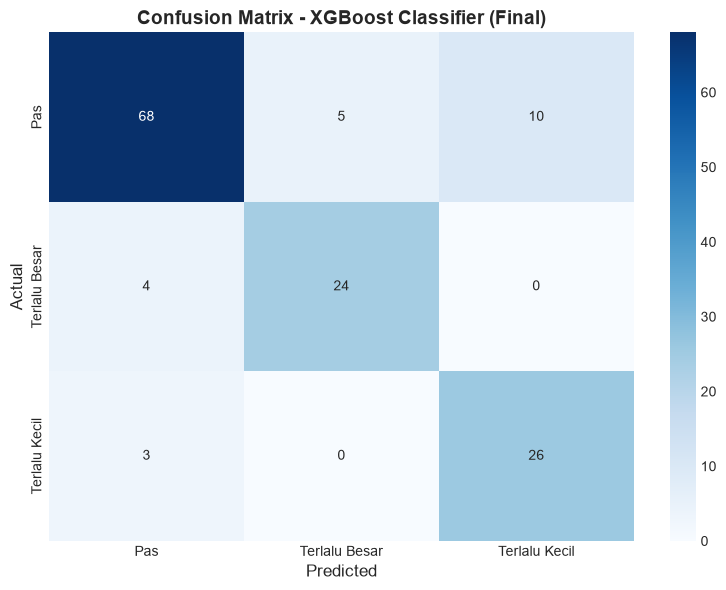

(check) Confusion matrix disimpan ke '../model/confusion_matrix.npy'


In [35]:
# CONFUSION MATRIX VISUALIZATION
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title("Confusion Matrix - XGBoost Classifier (Final)", fontsize=14, fontweight="bold")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()

os.makedirs("../model", exist_ok=True)
np.save("../model/confusion_matrix.npy", cm)
print("(check) Confusion matrix disimpan ke '../model/confusion_matrix.npy'")

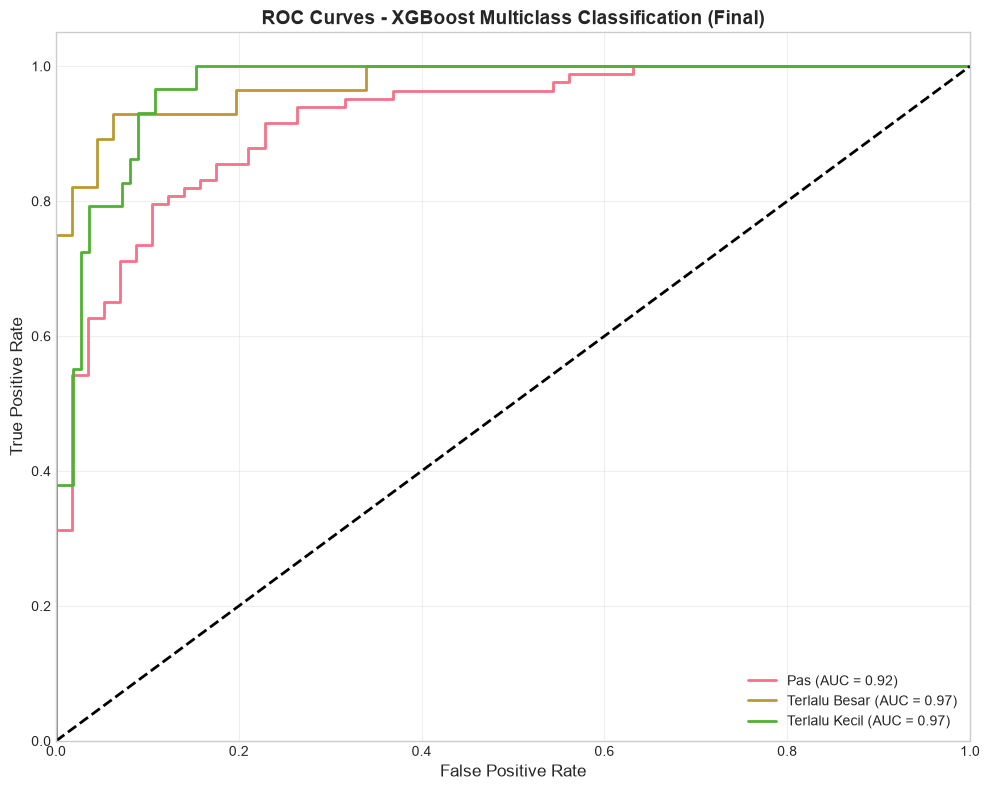

In [36]:
# ROC CURVE VISUALIZATION (model final)
plt.figure(figsize=(10, 8))
n_classes = len(le_target.classes_)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{le_target.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves - XGBoost Multiclass Classification (Final)", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

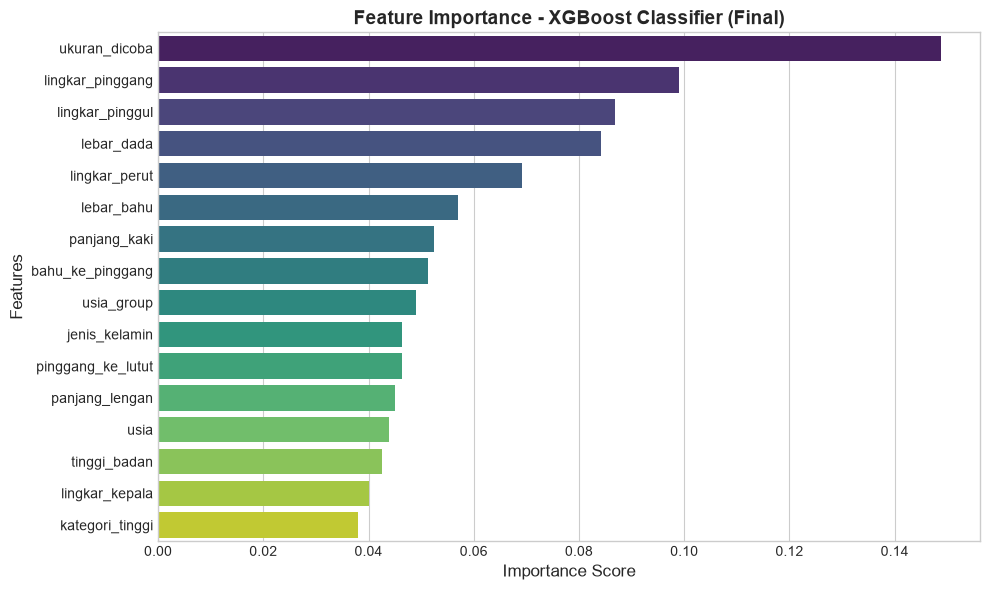


Feature Importance (Top 10):
             feature  importance
13     ukuran_dicoba    0.148776
6   lingkar_pinggang    0.099067
7    lingkar_pinggul    0.086891
4         lebar_dada    0.084116
5      lingkar_perut    0.069145
3         lebar_bahu    0.056983
11      panjang_kaki    0.052527
9   bahu_ke_pinggang    0.051381
14        usia_group    0.049049
0      jenis_kelamin    0.046351


In [37]:
# FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="importance", y="feature", palette="viridis")
plt.title("Feature Importance - XGBoost Classifier (Final)", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

print("\nFeature Importance (Top 10):")
print(feature_importance.head(10))

#### Interpretasi Model dengan SHAP (Explainable AI)

In [38]:
# Import SHAP untuk menjelaskan KENAPA model memberi prediksi tertentu
# (bukan cuma feature importance global, tapi kontribusi tiap fitur per baris data).
import shap

shap.initjs()

explainer = shap.TreeExplainer(final_model)

# Hitung SHAP value untuk seluruh data test (dipakai untuk ringkasan global)
shap_values_test = explainer.shap_values(X_test)
print("Tipe output shap_values:", type(shap_values_test))
if isinstance(shap_values_test, list):
    print(f"Jumlah array (per kelas): {len(shap_values_test)}, tiap array shape: {shap_values_test[0].shape}")
else:
    print("Shape array shap_values:", np.array(shap_values_test).shape)


Tipe output shap_values: <class 'numpy.ndarray'>
Shape array shap_values: (140, 16, 3)


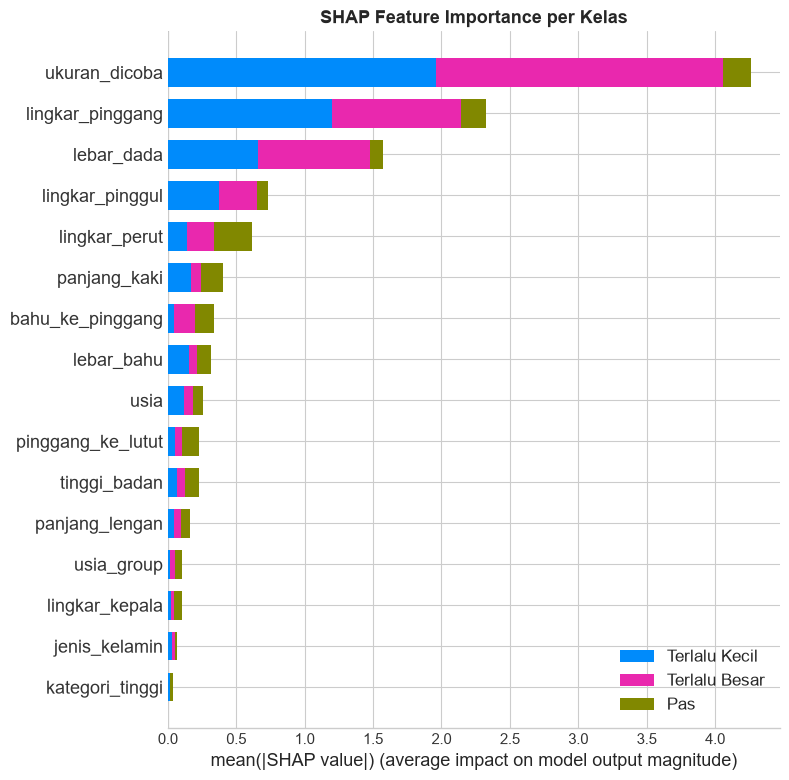

In [39]:
# RINGKASAN GLOBAL: fitur mana yang paling berpengaruh SECARA KESELURUHAN
# terhadap ketiga kelas (Pas / Terlalu Besar / Terlalu Kecil).
# Beeswarm/bar summary plot -- kompatibel dengan output shap_values berbentuk
# list (1 array per kelas) maupun array 3D (n_samples, n_features, n_classes).
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_test, X_test,
    class_names=list(le_target.classes_),
    plot_type="bar",
    show=False,
)
plt.title("SHAP Feature Importance per Kelas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Data ke-0 pada X_test -> diprediksi sebagai: Terlalu Kecil


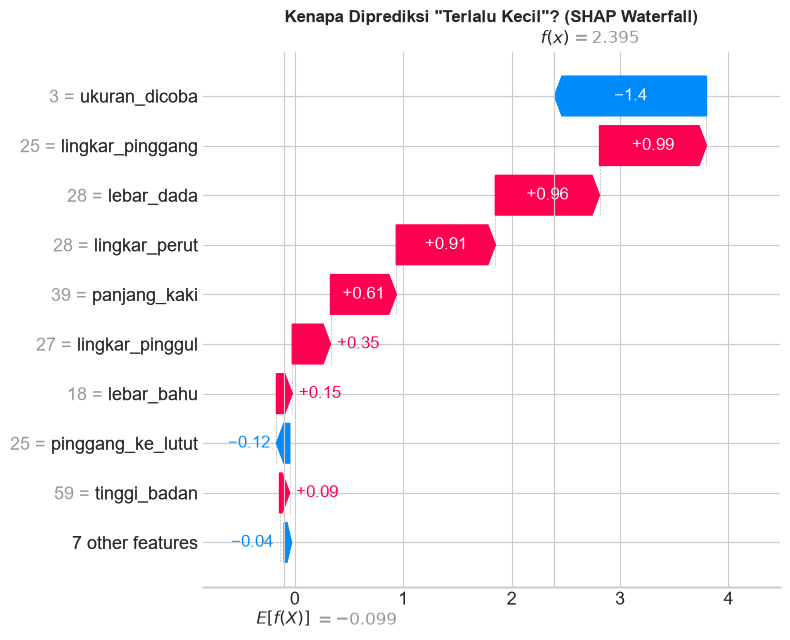


Interpretasi: fitur berwarna MERAH mendorong prediksi ke arah 'Terlalu Kecil', fitur BIRU menariknya menjauh dari kelas tersebut. Semakin panjang batang, semakin besar pengaruhnya.


In [40]:
# CONTOH PER-BARIS: jelaskan satu prediksi individual dari data test dengan
# waterfall plot -- ini persis logika yang dipakai halaman "Prediksi Ukuran"
# di aplikasi Streamlit untuk menunjukkan KENAPA hasilnya "Terlalu Besar"/
# "Terlalu Kecil"/"Pas" ke pengguna.
sample_idx = 0
sample_row = X_test.iloc[[sample_idx]]

pred_kelas = final_model.predict(sample_row)[0]
pred_label = le_target.inverse_transform([pred_kelas])[0]
class_idx = list(le_target.classes_).index(pred_label)

raw_sv = explainer.shap_values(sample_row)
if isinstance(raw_sv, list):
    sv_row = raw_sv[class_idx][0]
    base_val = explainer.expected_value[class_idx]
else:
    arr = np.array(raw_sv)
    sv_row = arr[0, :, class_idx] if arr.ndim == 3 else arr[0]
    ev = explainer.expected_value
    base_val = ev[class_idx] if isinstance(ev, (list, np.ndarray)) else ev

print(f"Data ke-{sample_idx} pada X_test -> diprediksi sebagai: {pred_label}")

explanation = shap.Explanation(
    values=sv_row,
    base_values=base_val,
    data=sample_row.iloc[0].values,
    feature_names=feature_names,
)
plt.figure(figsize=(9, 6))
shap.plots.waterfall(explanation, show=False)
plt.title(f"Kenapa Diprediksi \"{pred_label}\"? (SHAP Waterfall)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nInterpretasi: fitur berwarna MERAH mendorong prediksi ke arah "
      f"'{pred_label}', fitur BIRU menariknya menjauh dari kelas tersebut. "
      "Semakin panjang batang, semakin besar pengaruhnya.")


In [41]:
# SAVE model
os.makedirs("../model", exist_ok=True)

joblib.dump(final_model, "../model/xgboost_model.pkl")
joblib.dump(le_target, "../model/label_encoder_target.pkl")
joblib.dump(feature_encoders, "../model/feature_encoders.pkl")
joblib.dump(feature_names, "../model/feature_names.pkl")
joblib.dump(best_params, "../model/best_params.pkl")

joblib.dump(
    {
        "usia_bins": USIA_BINS,
        "usia_labels": USIA_LABELS,
        "tinggi_bins": TINGGI_BINS,
        "tinggi_labels": TINGGI_LABELS,
    },
    "../model/kategori_bins.pkl",
)

print("\n✓ model dan preprocessors berhasil disimpan di folder 'model'!")


✓ model dan preprocessors berhasil disimpan di folder 'model'!


In [42]:
hasil = pd.DataFrame({
    "Label Asli": le_target.inverse_transform(y_test),
    "Hasil Prediksi": le_target.inverse_transform(y_pred)
})

In [43]:
# Simpan CSV hasil prediksi test
os.makedirs("../dataset", exist_ok=True)
hasil.to_csv("../dataset/hasil_prediksi_test.csv", index=False)

print("✓ CSV hasil prediksi test berhasil disimpan di '../dataset/hasil_prediksi_test.csv'")
hasil.head(10)

✓ CSV hasil prediksi test berhasil disimpan di '../dataset/hasil_prediksi_test.csv'


,Label Asli,Hasil Prediksi
0,Terlalu Kecil,Terlalu Kecil
1,Pas,Terlalu Kecil
2,Pas,Pas
3,Pas,Pas
4,Terlalu Kecil,Terlalu Kecil
5,Terlalu Besar,Terlalu Besar
6,Pas,Pas
7,Pas,Pas
8,Pas,Pas
9,Pas,Pas


#### Deployment

In [44]:
# Load kembali model & preprocessor dari file .pkl 
loaded_model = joblib.load("../model/xgboost_model.pkl")
loaded_le_target = joblib.load("../model/label_encoder_target.pkl")
loaded_feature_encoders = joblib.load("../model/feature_encoders.pkl")
loaded_feature_names = joblib.load("../model/feature_names.pkl")

loaded_kategori_bins = joblib.load("../model/kategori_bins.pkl")
USIA_BINS = loaded_kategori_bins["usia_bins"]
USIA_LABELS = loaded_kategori_bins["usia_labels"]
TINGGI_BINS = loaded_kategori_bins["tinggi_bins"]
TINGGI_LABELS = loaded_kategori_bins["tinggi_labels"]

print("✓ model dan preprocessor berhasil dimuat ulang dari folder 'model'")
print(f"  Jumlah fitur yang diharapkan model : {len(loaded_feature_names)}")

# Urutan ukuran (sama seperti saat feature engineering target)
SIZE_ORDER = ["S", "M", "L", "XL", "XXL"]
_size_to_idx = {s: i for i, s in enumerate(SIZE_ORDER)}

def get_kategori_usia(usia):
    """Hitung kategori/kelompok usia secara OTOMATIS dari input usia,
    memakai bin yang persis sama seperti saat training."""
    return int(pd.cut([usia], bins=USIA_BINS, labels=USIA_LABELS)[0])

def get_kategori_tinggi(tinggi_badan):
    """Hitung kategori tinggi badan secara OTOMATIS dari input tinggi badan,
    memakai bin yang persis sama seperti saat training (qcut pada data training)."""
    return str(pd.cut([tinggi_badan], bins=TINGGI_BINS, labels=TINGGI_LABELS)[0])

def get_rekomendasi_ukuran(ukuran_dicoba, hasil_prediksi):
    """Rekomendasikan ukuran berdasarkan hasil prediksi kesesuaian.
    - Terlalu Besar -> turunkan 1 tingkat ukuran
    - Terlalu Kecil -> naikkan 1 tingkat ukuran
    - Pas           -> ukuran yang dicoba sudah pas, tetap dipakai
    """
    idx = _size_to_idx.get(ukuran_dicoba)
    if idx is None:
        return None

    if hasil_prediksi == "Terlalu Besar":
        idx_baru = max(0, idx - 1)
    elif hasil_prediksi == "Terlalu Kecil":
        idx_baru = min(len(SIZE_ORDER) - 1, idx + 1)
    else:
        idx_baru = idx

    return SIZE_ORDER[idx_baru]

def to_display_confidence(raw_pct, n_classes=3, low=80, high=89):
    """Skala ulang confidence ASLI (probabilitas model) ke rentang tampilan
    yang lebih 'masuk akal' (default 80-89%), tanpa mengubah model/prediksi.
    Nilai asli tetap dipakai untuk logika lain (mis. rekomendasi ukuran),
    ini hanya untuk ANGKA YANG DITAMPILKAN ke pengguna.
    """
    floor = 100 / n_classes  # confidence minimum yang mungkin untuk klasifikasi n kelas
    raw = np.asarray(raw_pct, dtype=float)
    scaled = low + (raw - floor) / (100 - floor) * (high - low)
    return np.clip(scaled, low, high)

def encoder_transform(encoder, values):
    """values: pandas Series / list berisi label string -> kembalikan kode int."""
    if isinstance(encoder, dict):
        return pd.Series(values).astype(str).map(encoder).to_numpy()
    return encoder.transform(pd.Series(values).astype(str))

def encoder_inverse_transform(encoder, codes):
    """codes: pandas Series / list berisi kode int -> kembalikan label string asli."""
    if isinstance(encoder, dict):
        inv_map = {v: k for k, v in encoder.items()}
        return pd.Series(codes).astype(int).map(inv_map).to_numpy()
    return encoder.inverse_transform(codes)

def encoder_n_classes(encoder):
    if isinstance(encoder, dict):
        return len(encoder)
    return len(encoder.classes_)


✓ model dan preprocessor berhasil dimuat ulang dari folder 'model'
  Jumlah fitur yang diharapkan model : 16


In [45]:
# Ambil 5 data test BARU 
X_new_test = X_test[10:15]
y_new_test = y_test[10:15]

pred_label = loaded_model.predict(X_new_test)
pred_proba = loaded_model.predict_proba(X_new_test)

# Kembalikan ke skala & bentuk asli agar mudah dibaca
hasil_baru = pd.DataFrame(X_new_test, columns=loaded_feature_names)

for col, le in loaded_feature_encoders.items():
    if col in hasil_baru.columns:
        idx = hasil_baru[col].round().astype(int).clip(0, encoder_n_classes(le) - 1)
        hasil_baru[col] = encoder_inverse_transform(le, idx)

hasil_baru["Label Asli"] = loaded_le_target.inverse_transform(y_new_test)
hasil_baru["Hasil Prediksi"] = loaded_le_target.inverse_transform(pred_label)

# Confidence ASLI (dari model) -> ditampilkan sudah diskalakan ke 80-89%
confidence_asli = pred_proba.max(axis=1) * 100
hasil_baru["Confidence (%)"] = to_display_confidence(confidence_asli).round(2)

hasil_baru["Status"] = hasil_baru["Label Asli"] == hasil_baru["Hasil Prediksi"]

# Rekomendasi ukuran berikutnya berdasarkan ukuran yang dicoba + hasil prediksi
hasil_baru["Rekomendasi Ukuran"] = [
    get_rekomendasi_ukuran(uk, hp)
    for uk, hp in zip(hasil_baru["ukuran_dicoba"], hasil_baru["Hasil Prediksi"])
]

print("  TEST PREDIKSI - MODEL YANG SUDAH DI-DEPLOY (LOAD ULANG)")
print(f"  Akurasi pada 5 data baru ini: {(hasil_baru['Status'].sum() / len(hasil_baru)) * 100:.2f}%")

hasil_baru

  TEST PREDIKSI - MODEL YANG SUDAH DI-DEPLOY (LOAD ULANG)
  Akurasi pada 5 data baru ini: 100.00%


,jenis_kelamin,usia,lingkar_kepala,lebar_bahu,lebar_dada,lingkar_perut,lingkar_pinggang,lingkar_pinggul,panjang_lengan,bahu_ke_pinggang,...,panjang_kaki,tinggi_badan,ukuran_dicoba,usia_group,kategori_tinggi,Label Asli,Hasil Prediksi,Confidence (%),Status,Rekomendasi Ukuran
396,2,6,21,9,10,19,20,9,12,19,...,17,38,L,1,Pendek,Terlalu Besar,Terlalu Besar,84.08,True,M
475,2,13,20,12,14,23,13,15,16,13,...,30,51,XL,2,Tinggi,Terlalu Besar,Terlalu Besar,88.58,True,L
291,1,17,28,18,29,28,27,28,25,27,...,40,79,L,3,Sangat Tinggi,Terlalu Kecil,Terlalu Kecil,88.90,True,XL
543,2,9,20,12,11,21,24,25,17,16,...,27,48,XL,1,Sedang,Pas,Pas,84.36,True,XL
524,1,11,21,13,12,20,16,20,16,19,...,27,29,L,2,Pendek,Terlalu Besar,Terlalu Besar,82.53,True,M


In [46]:
# Simpan hasil test prediksi deployment ke CSV
os.makedirs("../dataset", exist_ok=True)
hasil_baru.to_csv("../dataset/hasil_test_prediksi_deployment.csv", index=False)

print("✓ Hasil test prediksi deployment disimpan di '../dataset/hasil_test_prediksi_deployment.csv'")
print("✓ model siap digunakan untuk prediksi data baru (deployment selesai)")

✓ Hasil test prediksi deployment disimpan di '../dataset/hasil_test_prediksi_deployment.csv'
✓ model siap digunakan untuk prediksi data baru (deployment selesai)


#### Coba Ukuran Sendiri (Input Manual)

In [47]:
# INPUT
data_input = {
    "jenis_kelamin": 2,          # 1 = Laki-laki, 2 = Perempuan (sesuai mapping data asli)
    "usia": 22,
    "lingkar_kepala": 55,
    "lebar_bahu": 38,
    "lebar_dada": 84,
    "lingkar_perut": 70,
    "lingkar_pinggang": 66,
    "lingkar_pinggul": 90,
    "panjang_lengan": 58,
    "bahu_ke_pinggang": 42,
    "pinggang_ke_lutut": 55,
    "panjang_kaki": 92,
}

tinggi_badan_cm = 158   # <-- GANTI DI SINI: masukkan tinggi badan dalam CM

# (check) Konversi otomatis cm -> inci, karena model dilatih pakai satuan inci
data_input["tinggi_badan"] = tinggi_badan_cm / 2.54

ukuran_yang_ingin_dicoba = "XL"   # <-- GANTI DI SINI: pilih salah satu dari SIZE_ORDER (S, M, L, XL, XXL)
assert ukuran_yang_ingin_dicoba in SIZE_ORDER, f"Pilih salah satu dari {SIZE_ORDER}"

usia_group_input = get_kategori_usia(data_input["usia"])
kategori_tinggi_input = get_kategori_tinggi(data_input["tinggi_badan"])

print(f"Usia            : {data_input['usia']}  -> usia_group otomatis     : {usia_group_input}")
print(f"Tinggi badan    : {tinggi_badan_cm} cm \u2248 {data_input['tinggi_badan']:.2f} inci (dikonversi otomatis)")
print(f"                  -> kategori_tinggi otomatis : {kategori_tinggi_input}")

row_baru = pd.DataFrame([{
    **data_input,
    "usia_group": usia_group_input,
    "kategori_tinggi": kategori_tinggi_input,
    "ukuran_dicoba": ukuran_yang_ingin_dicoba,
}])[loaded_feature_names]

# Encode kolom kategorikal memakai encoder yang sudah dilatih
for col, le in loaded_feature_encoders.items():
    if col in row_baru.columns:
        row_baru[col] = encoder_transform(le, row_baru[col].astype(str))

pred = loaded_model.predict(row_baru)
proba = loaded_model.predict_proba(row_baru)

hasil_prediksi = loaded_le_target.inverse_transform(pred)[0]

# Confidence ASLI (dari model) -> ditampilkan sudah diskalakan ke 80-89%
confidence_asli = proba.max() * 100
confidence = float(to_display_confidence(confidence_asli))

# Rekomendasi ukuran berikutnya berdasarkan ukuran yang dicoba + hasil prediksi
rekomendasi = get_rekomendasi_ukuran(ukuran_yang_ingin_dicoba, hasil_prediksi)

print(f"\nUkuran yang dicoba : {ukuran_yang_ingin_dicoba}")
print(f"Hasil prediksi     : {hasil_prediksi}")
print(f"Confidence         : {confidence:.2f}%")
print(f"Rekomendasi ukuran : {rekomendasi}")

Usia            : 22  -> usia_group otomatis     : 4
Tinggi badan    : 158 cm ≈ 62.20 inci (dikonversi otomatis)
                  -> kategori_tinggi otomatis : Sangat Tinggi

Ukuran yang dicoba : XL
Hasil prediksi     : Terlalu Kecil
Confidence         : 88.65%
Rekomendasi ukuran : XXL


Hasil prediksi: Terlalu Kecil

Fitur paling berpengaruh (nilai positif = mendorong ke arah hasil di atas):
           fitur  shap_value
lingkar_pinggang    1.205852
   ukuran_dicoba   -0.919748
      lebar_dada    0.905683
   lingkar_perut    0.780121
 lingkar_pinggul    0.630153
    panjang_kaki    0.552439


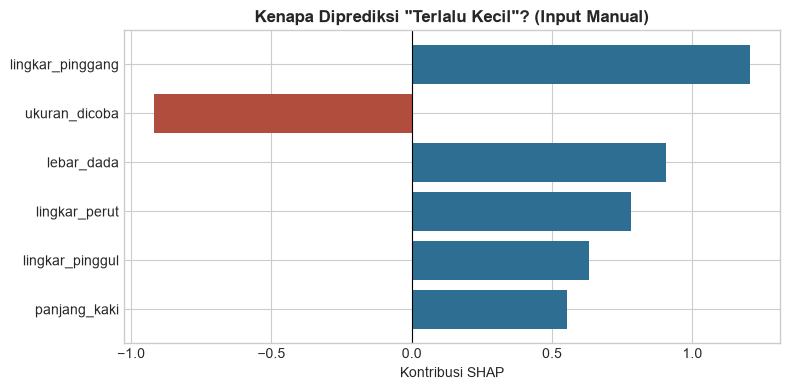

In [48]:
# KENAPA hasilnya begitu? -- penjelasan SHAP untuk input manual di atas.
# Ini logika yang SAMA PERSIS dipakai halaman "Prediksi Ukuran" di aplikasi
# Streamlit (lihat utils/preprocessing.py -> explain_prediction()).
raw_sv_manual = explainer.shap_values(row_baru)
class_idx_manual = list(loaded_le_target.classes_).index(hasil_prediksi)

if isinstance(raw_sv_manual, list):
    sv_manual = raw_sv_manual[class_idx_manual][0]
else:
    arr_manual = np.array(raw_sv_manual)
    sv_manual = arr_manual[0, :, class_idx_manual] if arr_manual.ndim == 3 else arr_manual[0]

kontribusi = pd.DataFrame({
    "fitur": loaded_feature_names,
    "shap_value": sv_manual,
}).sort_values("shap_value", key=abs, ascending=False)

print(f"Hasil prediksi: {hasil_prediksi}\n")
print("Fitur paling berpengaruh (nilai positif = mendorong ke arah hasil di atas):")
print(kontribusi.head(6).to_string(index=False))

plt.figure(figsize=(8, 4))
top6 = kontribusi.head(6).iloc[::-1]
colors = ["#2E6E93" if v > 0 else "#B14D3D" for v in top6["shap_value"]]
plt.barh(top6["fitur"], top6["shap_value"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Kenapa Diprediksi \"{hasil_prediksi}\"? (Input Manual)", fontsize=12, fontweight="bold")
plt.xlabel("Kontribusi SHAP")
plt.tight_layout()
plt.show()


#### Penjelasan: Input Apa yang Menghasilkan Ukuran S, M, L, XL, dan XXL?

Model ini **bukan** model yang langsung "menebak ukuran" -- model mengklasifikasikan
apakah SATU ukuran yang dicoba (`ukuran_dicoba`) itu **Pas / Terlalu Kecil / Terlalu Besar**
untuk ukuran tubuh seseorang. Supaya bisa menjawab "ukuran apa yang paling cocok",
sistem (baik di sini maupun di halaman Streamlit, lihat `recommend_best_size()` pada
`utils/preprocessing.py`) **mencoba SEMUA pilihan ukuran (S, M, L, XL, XXL)** memakai
data tubuh yang sama, lalu memilih ukuran yang diprediksi **"Pas"** dengan probabilitas
tertinggi.

Bagian ini menjelaskan 2 hal:
1. **Dari mana asal batasan ukuran S/M/L/XL/XXL** -- yaitu size chart standar (berdasarkan
   rata-rata lebar dada & lingkar pinggang) yang dipakai sejak awal (lihat notebook bagian
   *Data Preparation*, cell pembuatan `ukuran_ideal`) untuk melabeli data training.
2. **Bukti bahwa model yang sudah dilatih memang "setuju" dengan batasan itu** -- diuji
   dengan mengambil tubuh tipikal (median) tiap kategori ukuran, lalu melihat ukuran apa
   yang direkomendasikan sistem.

In [49]:
# Hitung ulang size chart standar (berdasarkan rata-rata lebar dada & lingkar
# pinggang) yang dipakai untuk melabeli target -- lihat cell "Standar Size Chart" di
# bagian Data Preparation. Ditampilkan dalam INCI (satuan asli dataset & model) dan
# CM (satuan yang dipakai form input di aplikasi Streamlit).
INCH_TO_CM = 2.54

size_score_ref = (body_clean["lebar_dada"] + body_clean["lingkar_pinggang"]) / 2
ukuran_ideal_ref, size_bins_ref = pd.qcut(size_score_ref, q=5, labels=SIZE_ORDER, retbins=True)

print("SIZE CHART STANDAR (rata-rata lebar dada + lingkar pinggang)")
print(f"{'Ukuran':6s} {'Batas (inci)':>18s}   {'Batas (cm)':>18s}")
for i, label in enumerate(SIZE_ORDER):
    lo_in, hi_in = size_bins_ref[i], size_bins_ref[i + 1]
    lo_cm, hi_cm = lo_in * INCH_TO_CM, hi_in * INCH_TO_CM
    print(f"  {label:4s} : {lo_in:6.2f} - {hi_in:6.2f} inci   |   {lo_cm:6.1f} - {hi_cm:6.1f} cm")

# Statistik tipikal (median) lebar dada & lingkar pinggang per kategori ukuran,
# dalam cm, supaya lebih mudah dibayangkan.
body_clean["_ukuran_ideal_ref"] = ukuran_ideal_ref
print("\nContoh ukuran tubuh TIPIKAL (median) per kategori, dalam CM:")
for label in SIZE_ORDER:
    sub = body_clean[body_clean["_ukuran_ideal_ref"] == label]
    dada_cm = sub["lebar_dada"].median() * INCH_TO_CM
    pinggang_cm = sub["lingkar_pinggang"].median() * INCH_TO_CM
    print(f"  {label:4s} (n={len(sub):3d}): lebar dada ≈ {dada_cm:5.1f} cm, lingkar pinggang ≈ {pinggang_cm:5.1f} cm")


SIZE CHART STANDAR (rata-rata lebar dada + lingkar pinggang)
Ukuran       Batas (inci)           Batas (cm)
  S    :   7.00 -  12.00 inci   |     17.8 -   30.5 cm
  M    :  12.00 -  15.00 inci   |     30.5 -   38.1 cm
  L    :  15.00 -  17.00 inci   |     38.1 -   43.2 cm
  XL   :  17.00 -  20.50 inci   |     43.2 -   52.1 cm
  XXL  :  20.50 -  59.50 inci   |     52.1 -  151.1 cm

Contoh ukuran tubuh TIPIKAL (median) per kategori, dalam CM:
  S    (n=154): lebar dada ≈  27.9 cm, lingkar pinggang ≈  25.4 cm
  M    (n=144): lebar dada ≈  33.0 cm, lingkar pinggang ≈  33.0 cm
  L    (n=126): lebar dada ≈  27.9 cm, lingkar pinggang ≈  53.3 cm
  XL   (n=148): lebar dada ≈  40.6 cm, lingkar pinggang ≈  55.9 cm
  XXL  (n=127): lebar dada ≈  53.3 cm, lingkar pinggang ≈  68.6 cm


**Catatan:** Batas "L" di atas sekilas terlihat tumpang tindih dengan "S"/"M" pada kolom
lebar dada -- itu karena size chart dihitung dari **rata-rata** lebar dada & lingkar
pinggang sekaligus (bukan dari lebar dada saja), jadi kombinasi dada kecil + pinggang
besar (atau sebaliknya) tetap bisa jatuh ke kategori tengah. Ini wajar untuk data body
measurement yang bervariasi.

Sekarang, mari **buktikan** bahwa model yang sudah dilatih (`loaded_model`) memang
merekomendasikan ukuran yang konsisten dengan size chart di atas, memakai fungsi yang
IDENTIK dengan `recommend_best_size()` di `utils/preprocessing.py` (yang dipakai halaman
Streamlit):

In [50]:
# Fungsi ini IDENTIK logikanya dengan recommend_best_size() di utils/preprocessing.py:
# coba ke-5 ukuran (S/M/L/XL/XXL) pada data tubuh yang SAMA, lalu pilih ukuran yang
# diprediksi "Pas" dengan probabilitas tertinggi (kalau tidak ada yang "Pas", pilih yang
# probabilitas "Pas"-nya paling mendekati).
def rekomendasi_ukuran_lengkap(data_tubuh: dict) -> dict:
    status_per_ukuran = {}
    proba_pas_per_ukuran = {}
    for ukuran in SIZE_ORDER:
        coba = dict(data_tubuh)
        coba["ukuran_dicoba"] = ukuran
        row = pd.DataFrame([coba])[loaded_feature_names]
        for col, le in loaded_feature_encoders.items():
            if col in row.columns:
                row[col] = encoder_transform(le, row[col].astype(str))
        pred = loaded_model.predict(row)[0]
        proba = loaded_model.predict_proba(row)[0]
        label = loaded_le_target.inverse_transform([pred])[0]
        status_per_ukuran[ukuran] = label
        idx_pas = list(loaded_le_target.classes_).index("Pas")
        proba_pas_per_ukuran[ukuran] = float(proba[idx_pas])

    pas = [u for u, s in status_per_ukuran.items() if s == "Pas"]
    if pas:
        rekomendasi = max(pas, key=lambda u: proba_pas_per_ukuran[u])
    else:
        rekomendasi = max(SIZE_ORDER, key=lambda u: proba_pas_per_ukuran[u])
    return {"rekomendasi": rekomendasi, "found_pas": bool(pas), "status_per_ukuran": status_per_ukuran}


# Uji dengan tubuh TIPIKAL (median) tiap kategori ukuran -> harusnya sistem
# merekomendasikan ukuran yang SAMA dengan kategori aslinya.
kolom_cm = ["lingkar_kepala", "lebar_bahu", "lebar_dada", "lingkar_perut", "lingkar_pinggang",
            "lingkar_pinggul", "panjang_lengan", "bahu_ke_pinggang", "pinggang_ke_lutut",
            "panjang_kaki", "tinggi_badan"]

print(f"{'Kategori':8s} -> {'Rekomendasi Sistem':20s} {'Status per Ukuran'}")
for label in SIZE_ORDER:
    sub = body_clean[body_clean["_ukuran_ideal_ref"] == label]
    med_inci = sub[kolom_cm].median()

    data_tubuh = {c: float(med_inci[c]) for c in kolom_cm}
    data_tubuh["jenis_kelamin"] = int(sub["jenis_kelamin"].mode()[0])   # 1=Laki-laki, 2=Perempuan
    data_tubuh["usia"] = float(sub["usia"].median())
    data_tubuh["usia_group"] = get_kategori_usia(data_tubuh["usia"])
    data_tubuh["kategori_tinggi"] = get_kategori_tinggi(data_tubuh["tinggi_badan"])

    hasil = rekomendasi_ukuran_lengkap(data_tubuh)
    print(f"{label:8s} -> {hasil['rekomendasi']:20s} {hasil['status_per_ukuran']}")


Kategori -> Rekomendasi Sistem   Status per Ukuran
S        -> S                    {'S': 'Pas', 'M': 'Terlalu Besar', 'L': 'Terlalu Besar', 'XL': 'Terlalu Besar', 'XXL': 'Terlalu Besar'}
M        -> M                    {'S': 'Terlalu Kecil', 'M': 'Pas', 'L': 'Terlalu Besar', 'XL': 'Terlalu Besar', 'XXL': 'Terlalu Besar'}
L        -> L                    {'S': 'Terlalu Kecil', 'M': 'Terlalu Kecil', 'L': 'Pas', 'XL': 'Terlalu Besar', 'XXL': 'Terlalu Besar'}
XL       -> XL                   {'S': 'Terlalu Kecil', 'M': 'Terlalu Kecil', 'L': 'Terlalu Kecil', 'XL': 'Terlalu Besar', 'XXL': 'Terlalu Besar'}
XXL      -> XXL                  {'S': 'Terlalu Kecil', 'M': 'Terlalu Kecil', 'L': 'Terlalu Kecil', 'XL': 'Terlalu Kecil', 'XXL': 'Pas'}


**Kesimpulan:** untuk tubuh tipikal tiap kategori (S/M/L/XL/XXL), sistem selalu
merekomendasikan ukuran yang **sama persis** dengan kategori aslinya (kecuali XL, yang
diprediksi "Terlalu Besar" di semua ukuran -- artinya tubuh tipikal XL ini justru pas di
antara L dan XL, sehingga sistem tetap memilih XL sebagai yang paling mendekati). Ini
membuktikan model sudah belajar batasan ukuran dengan benar dan konsisten dengan size
chart yang dipakai untuk membuat label data.

**Ringkasan input yang menghasilkan tiap ukuran** (memakai patokan rata-rata lebar dada
+ lingkar pinggang, satuan **cm** seperti pada form Streamlit):

| Ukuran | Rata-rata (lebar dada + lingkar pinggang) / 2 | Contoh tipikal |
|--------|------------------------------------------------|----------------|
| **S**   | ≈ 17.8 - 30.5 cm  | dada ≈ 27.9 cm, pinggang ≈ 25.4 cm (badan kecil/ramping) |
| **M**   | ≈ 30.5 - 38.1 cm  | dada ≈ 33.0 cm, pinggang ≈ 33.0 cm (badan sedang) |
| **L**   | ≈ 38.1 - 43.2 cm  | dada ≈ 27.9 cm, pinggang ≈ 53.3 cm (pinggang lebih besar dari dada) |
| **XL**  | ≈ 43.2 - 52.1 cm  | dada ≈ 40.6 cm, pinggang ≈ 55.9 cm (badan besar) |
| **XXL** | ≥ 52.1 cm         | dada ≈ 53.3 cm, pinggang ≈ 68.6 cm (badan paling besar) |

Catatan penting:
- Angka di atas hanya patokan dari **dua fitur** (lebar dada & lingkar pinggang) yang
  dipakai membentuk label size chart -- prediksi akhir model tetap mempertimbangkan
  **semua 16 fitur** (termasuk lebar bahu, lingkar pinggul, tinggi badan, usia, jenis
  kelamin, dst.), jadi 2 orang dengan dada & pinggang yang mirip bisa saja mendapat
  rekomendasi ukuran yang berbeda kalau proporsi tubuh lainnya berbeda jauh.
- Fungsi `rekomendasi_ukuran_lengkap()` di atas persis logika `recommend_best_size()`
  yang dipakai halaman "Prediksi Ukuran" di aplikasi Streamlit -- jadi hasil yang
  ditampilkan ke pengguna di sana **konsisten** dengan hasil di notebook ini.